In [66]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path 
from itertools import combinations 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.stats import ( friedmanchisquare, wilcoxon ) 
from IPython.display import display
pd.set_option("display.max_columns", None) 
pd.set_option("display.max_rows", 100) 
pd.set_option("display.width", 140) 
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [67]:
# ============================================================
# H4 — LOAD VISIT_DISPOSITION SHEET
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\bhara\OneDrive\Desktop\Capstone_Project-DAMO-6994-"
    r"\Capstone_Project-DAMO-6994-\Capstone_Project-DAMO-6994-"
    r"\data\cleaned dataset\Explanatory_and_Predictive_ED_Analytics_Dataset.xlsx"
)

DISPOSITION_SHEET = "Visit_Disposition"

if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"\nWorkbook not found:\n{INPUT_FILE}\n"
        "Please check the file path."
    )

visit_disposition_df = pd.read_excel(
    INPUT_FILE,
    sheet_name=DISPOSITION_SHEET
)

print("=" * 80)
print("H4 — VISIT DISPOSITION DATA")
print("=" * 80)

print(f"Rows loaded: {len(visit_disposition_df):,}")
print(f"Columns    : {list(visit_disposition_df.columns)}")

display(visit_disposition_df.head())

H4 — VISIT DISPOSITION DATA
Rows loaded: 936
Columns    : ['fiscal_year', 'fiscal_year_start', 'sex', 'visit_disposition', 'admission_flag', 'admission_status', 'age_group', 'population_category', 'ed_visits', 'median_los_minutes', 'median_los_hours', 'erbi']


,fiscal_year,fiscal_year_start,sex,visit_disposition,admission_flag,admission_status,age_group,population_category,ed_visits,median_los_minutes,median_los_hours,erbi
0,2021-2022,2021,Female,Admitted,1,Admitted,0-19,Pediatric & Youth,61448,450,7.5000,27651600
1,2021-2022,2021,Female,Admitted,1,Admitted,20-44,Young Adult,135970,702,11.7000,95450940
2,2021-2022,2021,Female,Admitted,1,Admitted,45-64,Middle Adult,154636,792,13.2000,122471712
3,2021-2022,2021,Female,Admitted,1,Admitted,65+,Older Adult,423379,966,16.1000,408984114
4,2021-2022,2021,Male,Admitted,1,Admitted,0-19,Pediatric & Youth,61089,420,7.0000,25657380


In [68]:
# ============================================================
# STANDARDIZE COLUMN NAMES & VALIDATE REQUIRED COLUMNS
# ============================================================

visit_disposition_df.columns = (
    visit_disposition_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

REQUIRED_COLUMNS = [
    "fiscal_year",
    "fiscal_year_start",
    "sex",
    "age_group",
    "visit_disposition",
    "ed_visits",
    "median_los_minutes"
]

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in visit_disposition_df.columns
]

if missing_columns:
    raise KeyError(
        "Missing required H4 columns: "
        + ", ".join(missing_columns)
    )

print("=" * 80)
print("REQUIRED COLUMNS VALIDATION")
print("=" * 80)
for col in REQUIRED_COLUMNS:
    print(f"  ✓ {col}")

REQUIRED COLUMNS VALIDATION
  ✓ fiscal_year
  ✓ fiscal_year_start
  ✓ sex
  ✓ age_group
  ✓ visit_disposition
  ✓ ed_visits
  ✓ median_los_minutes


In [69]:
# ============================================================
# H4 — CLEAN DATA & STANDARDIZE DISPOSITION CATEGORIES
# ============================================================

DISPOSITION_LEVELS = [
    "Admitted",
    "Death",
    "Discharged",
    "Intra-Facility Transfer",
    "Left Without Being Seen",
    "Transferred"
]

def standardize_disposition(value):
    value_lower = str(value).strip().lower()

    if "admitted" in value_lower:
        return "Admitted"

    if value_lower == "death" or "death" in value_lower:
        return "Death"

    if "discharged" in value_lower:
        return "Discharged"

    if (
        "intra-facility" in value_lower
        or "intra facility" in value_lower
    ):
        return "Intra-Facility Transfer"

    if (
        "left without being seen" in value_lower
        or "not seen" in value_lower
        or "lwbs" in value_lower
    ):
        return "Left Without Being Seen"

    if "transferred" in value_lower:
        return "Transferred"

    if "unknown" in value_lower:
        return "Unknown"

    return np.nan

h4_df = visit_disposition_df[
    REQUIRED_COLUMNS
].copy()

h4_df["fiscal_year_start"] = pd.to_numeric(
    h4_df["fiscal_year_start"],
    errors="coerce"
)

h4_df["ed_visits"] = pd.to_numeric(
    h4_df["ed_visits"],
    errors="coerce"
)

h4_df["median_los_minutes"] = pd.to_numeric(
    h4_df["median_los_minutes"],
    errors="coerce"
)

h4_df = h4_df[
    h4_df["median_los_minutes"].notna()
].copy()

h4_df = h4_df[
    h4_df["median_los_minutes"] >= 0
].copy()

h4_df["visit_disposition"] = (
    h4_df["visit_disposition"]
    .apply(standardize_disposition)
)

# Exclude 'Unknown' from primary inferential testing
h4_df = h4_df[
    h4_df["visit_disposition"].isin(
        DISPOSITION_LEVELS
    )
].copy()

print("=" * 80)
print("H4 CLEANED DATASET SUMMARY")
print("=" * 80)
print(f"Total primary observations : {len(h4_df):,}")
print(f"Fiscal years covered       : {h4_df['fiscal_year_start'].nunique()}")
print(f"Disposition levels         : {h4_df['visit_disposition'].nunique()}")
display(h4_df.head())

H4 CLEANED DATASET SUMMARY
Total primary observations : 912
Fiscal years covered       : 19
Disposition levels         : 6


,fiscal_year,fiscal_year_start,sex,age_group,visit_disposition,ed_visits,median_los_minutes
0,2021-2022,2021,Female,0-19,Admitted,61448,450
1,2021-2022,2021,Female,20-44,Admitted,135970,702
2,2021-2022,2021,Female,45-64,Admitted,154636,792
3,2021-2022,2021,Female,65+,Admitted,423379,966
4,2021-2022,2021,Male,0-19,Admitted,61089,420


In [70]:
# ============================================================
# H4 — DATA QUALITY CHECK
# ============================================================

print("=" * 80)
print("H4 DATA QUALITY CHECK")
print("=" * 80)

print(f"Aggregate records: {len(h4_df):,}")
print(f"Missing LOS      : {h4_df['median_los_minutes'].isna().sum():,}")
print(f"Negative LOS     : {(h4_df['median_los_minutes'] < 0).sum():,}")
print(f"Missing ED visits: {h4_df['ed_visits'].isna().sum():,}")

print("\nDisposition counts:")
display(
    h4_df["visit_disposition"]
    .value_counts()
    .reindex(DISPOSITION_LEVELS)
)

H4 DATA QUALITY CHECK
Aggregate records: 912
Missing LOS      : 0
Negative LOS     : 0
Missing ED visits: 0

Disposition counts:


visit_disposition
Admitted                   152
Death                      152
Discharged                 152
Intra-Facility Transfer    152
Left Without Being Seen    152
Transferred                152
Name: count, dtype: int64

In [71]:
# ============================================================
# H4 — MATCHED BLOCK STRUCTURE VALIDATION
# ============================================================

MATCH_COLUMNS = [
    "fiscal_year_start",
    "sex",
    "age_group"
]

structure_check = (
    h4_df
    .groupby(
        MATCH_COLUMNS,
        observed=True
    )[
        "visit_disposition"
    ]
    .nunique()
    .reset_index(
        name="Disposition_Count"
    )
)

print("=" * 80)
print("H4 MATCHED BLOCK VALIDATION")
print("=" * 80)

display(structure_check.head())

print(f"Total matched blocks                     : {len(structure_check):,}")
print(f"Minimum disposition categories per block : {structure_check['Disposition_Count'].min()}")
print(f"Maximum disposition categories per block : {structure_check['Disposition_Count'].max()}")

if not (structure_check["Disposition_Count"] == len(DISPOSITION_LEVELS)).all():
    incomplete_blocks = (
        structure_check[
            structure_check["Disposition_Count"] != len(DISPOSITION_LEVELS)
        ]
    )
    raise ValueError(
        "Incomplete matched disposition structure detected.\n"
        f"{incomplete_blocks}"
    )

print("\nStructure validation passed: All 152 blocks contain all 6 disposition categories.")

H4 MATCHED BLOCK VALIDATION


,fiscal_year_start,sex,age_group,Disposition_Count
0,2003,Female,0-19,6
1,2003,Female,20-44,6
2,2003,Female,45-64,6
3,2003,Female,65+,6
4,2003,Male,0-19,6


Total matched blocks                     : 152
Minimum disposition categories per block : 6
Maximum disposition categories per block : 6

Structure validation passed: All 152 blocks contain all 6 disposition categories.


In [72]:
# ============================================================
# H4 — DUPLICATE VALIDATION
# ============================================================

DUPLICATE_COLUMNS = [
    "fiscal_year_start",
    "sex",
    "age_group",
    "visit_disposition"
]

duplicate_mask = (
    h4_df
    .duplicated(
        subset=DUPLICATE_COLUMNS,
        keep=False
    )
)

duplicate_count = duplicate_mask.sum()

print("=" * 80)
print("H4 DUPLICATE VALIDATION")
print("=" * 80)

print(f"Duplicate matched observations: {duplicate_count:,}")

if duplicate_count > 0:
    display(
        h4_df[duplicate_mask].sort_values(DUPLICATE_COLUMNS)
    )
    raise ValueError(
        "Duplicate fiscal-year × sex × age-group × disposition observations detected. "
        "Resolve the source structure before running H4."
    )

print("Validation passed: Exactly 0 duplicate records.")

H4 DUPLICATE VALIDATION
Duplicate matched observations: 0
Validation passed: Exactly 0 duplicate records.


In [73]:
# ============================================================
# H4 — FRIEDMAN MATRIX & COMPLETE-CASE VALIDATION
# ============================================================

friedman_matrix = (
    h4_df
    .pivot(
        index=MATCH_COLUMNS,
        columns="visit_disposition",
        values="median_los_minutes"
    )
    .reindex(
        columns=DISPOSITION_LEVELS
    )
)

complete_matrix = (
    friedman_matrix
    .dropna(
        how="any"
    )
)

print("=" * 80)
print("H4 FRIEDMAN MATRIX")
print("=" * 80)

print(f"Matrix shape           : {friedman_matrix.shape}")
print(f"Complete matched blocks: {len(complete_matrix):,}")

if len(complete_matrix) < 2:
    raise ValueError(
        "Not enough complete matched blocks for the Friedman test."
    )

display(complete_matrix.head())

H4 FRIEDMAN MATRIX
Matrix shape           : (152, 6)
Complete matched blocks: 152


visit_disposition                   Admitted  Death  Discharged  Intra-Facility Transfer  Left Without Being Seen  Transferred
fiscal_year_start sex    age_group                                                                                            
2003              Female 0-19            249     29          98                      140                      100          171
                         20-44           301     42         121                      212                      115          210
                         45-64           307     35         126                      188                      115          246
                         65+             320     86         169                      208                      119          265
                  Male   0-19            235     37          96                      132                       98          164

In [74]:
# ============================================================
# H4 — PRIMARY FRIEDMAN TEST
# ============================================================

ALPHA = 0.05

friedman_statistic, p_value = friedmanchisquare(
    *[
        complete_matrix[
            disposition
        ].to_numpy()
        for disposition in DISPOSITION_LEVELS
    ]
)

degrees_of_freedom = (
    len(DISPOSITION_LEVELS) - 1
)

print("=" * 80)
print("H4 — FRIEDMAN TEST")
print("=" * 80)

print(f"Friedman χ²       : {friedman_statistic:.6f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value           : {p_value:.10g}")
print(f"Alpha (α)         : {ALPHA}")

H4 — FRIEDMAN TEST
Friedman χ²       : 703.725989
Degrees of freedom: 5
P-value           : 7.684532426e-150
Alpha (α)         : 0.05


In [75]:
# ============================================================
# H4 — KENDALL'S W EFFECT SIZE
# ============================================================

n_blocks = len(complete_matrix)
k_groups = len(DISPOSITION_LEVELS)

kendalls_w = (
    friedman_statistic
    / (
        n_blocks
        * (k_groups - 1)
    )
)

print("=" * 80)
print("H4 EFFECT SIZE — KENDALL'S W")
print("=" * 80)

print(f"Matched blocks (N)     : {n_blocks}")
print(f"Disposition groups (k) : {k_groups}")
print(f"Kendall's W            : {kendalls_w:.6f}")
print(f"W in [0, 1]            : {0 <= kendalls_w <= 1}")

H4 EFFECT SIZE — KENDALL'S W
Matched blocks (N)     : 152
Disposition groups (k) : 6
Kendall's W            : 0.925955
W in [0, 1]            : True


In [76]:
# ============================================================
# H4 — HYPOTHESIS DECISION
# ============================================================

if p_value < ALPHA:
    decision = "Reject H₀"
    conclusion = (
        "There is statistically significant evidence "
        "that reported median ED LOS differs across "
        "the major visit-disposition categories "
        "within the matched aggregate data."
    )
else:
    decision = "Fail to Reject H₀"
    conclusion = (
        "There is insufficient statistical evidence "
        "to conclude that reported median ED LOS differs "
        "across the major visit-disposition categories "
        "within the matched aggregate data."
    )

print("=" * 80)
print("H4 HYPOTHESIS DECISION")
print("=" * 80)

print(f"Decision   : {decision}")
print(f"\nConclusion :\n{conclusion}")

H4 HYPOTHESIS DECISION
Decision   : Reject H₀

Conclusion :
There is statistically significant evidence that reported median ED LOS differs across the major visit-disposition categories within the matched aggregate data.


In [77]:
# ============================================================
# H4 — WILCOXON POST-HOC TESTS & BONFERRONI CORRECTION
# ============================================================

pairwise_results = []

if p_value < ALPHA:
    for group1, group2 in combinations(DISPOSITION_LEVELS, 2):
        statistic, raw_p = wilcoxon(
            complete_matrix[group1],
            complete_matrix[group2],
            alternative="two-sided",
            zero_method="wilcox",
            method="auto"
        )
        pairwise_results.append({
            "Group_1": group1,
            "Group_2": group2,
            "Wilcoxon_Statistic": statistic,
            "Raw_P_Value": raw_p
        })

posthoc = pd.DataFrame(pairwise_results)

if not posthoc.empty:
    number_comparisons = len(posthoc)
    posthoc["Adjusted_P_Value"] = (
        posthoc["Raw_P_Value"] * number_comparisons
    ).clip(upper=1)

    posthoc["Significant"] = (
        posthoc["Adjusted_P_Value"] < ALPHA
    )

    posthoc = (
        posthoc
        .sort_values("Adjusted_P_Value")
        .reset_index(drop=True)
    )

    print("=" * 80)
    print("H4 POST-HOC PAIRWISE COMPARISONS (BONFERRONI-CORRECTED)")
    print("=" * 80)
    display(posthoc.round(6))

    if len(posthoc) != 15:
        raise ValueError(
            "Six disposition groups require exactly 15 pairwise comparisons."
        )
else:
    posthoc = pd.DataFrame(
        columns=[
            "Group_1",
            "Group_2",
            "Wilcoxon_Statistic",
            "Raw_P_Value",
            "Adjusted_P_Value",
            "Significant"
        ]
    )
    print("Friedman test was not significant; post-hoc comparisons were not performed.")

H4 POST-HOC PAIRWISE COMPARISONS (BONFERRONI-CORRECTED)


,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
0,Discharged,Transferred,0.0000,0.0000,0.0000,True
1,Left Without Being Seen,Transferred,0.0000,0.0000,0.0000,True
2,Death,Discharged,0.0000,0.0000,0.0000,True
3,Death,Left Without Being Seen,0.0000,0.0000,0.0000,True
4,Death,Transferred,0.0000,0.0000,0.0000,True
5,Admitted,Transferred,0.0000,0.0000,0.0000,True
6,Admitted,Discharged,0.0000,0.0000,0.0000,True
7,Admitted,Left Without Being Seen,0.0000,0.0000,0.0000,True
8,Admitted,Death,0.0000,0.0000,0.0000,True
9,Admitted,Intra-Facility Transfer,0.0000,0.0000,0.0000,True


In [78]:
# ============================================================
# H4 — PLANNED COMPARISONS
# ============================================================

PLANNED_PAIRS = [
    ("Admitted", "Discharged"),
    ("Admitted", "Left Without Being Seen")
]

planned_posthoc = (
    posthoc[
        posthoc.apply(
            lambda row:
                (
                    row["Group_1"],
                    row["Group_2"]
                ) in PLANNED_PAIRS
                or
                (
                    row["Group_2"],
                    row["Group_1"]
                ) in PLANNED_PAIRS,
            axis=1
        )
    ]
    .copy()
)

print("=" * 80)
print("H4 PLANNED SUBSTANTIVE COMPARISONS")
print("=" * 80)
display(planned_posthoc.round(6))

H4 PLANNED SUBSTANTIVE COMPARISONS


,Group_1,Group_2,Wilcoxon_Statistic,Raw_P_Value,Adjusted_P_Value,Significant
6,Admitted,Discharged,0.0000,0.0000,0.0000,True
7,Admitted,Left Without Being Seen,0.0000,0.0000,0.0000,True


In [79]:
# ============================================================
# H4 — DESCRIPTIVE SUMMARY
# ============================================================

h4_summary = (
    h4_df
    .groupby(
        "visit_disposition",
        observed=True
    )
    .agg(
        Median_Reported_LOS=(
            "median_los_minutes",
            "median"
        ),
        Mean_Reported_LOS=(
            "median_los_minutes",
            "mean"
        ),
        Aggregate_Visits=(
            "ed_visits",
            "sum"
        ),
        Matched_Blocks=(
            "fiscal_year_start",
            "count"
        )
    )
    .reindex(
        DISPOSITION_LEVELS
    )
    .reset_index()
)

print("=" * 80)
print("H4 DESCRIPTIVE SUMMARY")
print("=" * 80)
display(h4_summary.round(2))

H4 DESCRIPTIVE SUMMARY


,visit_disposition,Median_Reported_LOS,Mean_Reported_LOS,Aggregate_Visits,Matched_Blocks
0,Admitted,519.5000,504.6200,18004220,152
1,Death,37.5000,50.2700,182003,152
2,Discharged,145.0000,151.3500,145245540,152
3,Intra-Facility Transfer,198.5000,179.4000,909384,152
4,Left Without Being Seen,135.0000,134.1900,8492360,152
5,Transferred,246.0000,249.2500,2786266,152


In [80]:
# ============================================================
# H4 — ESTIMATED RESOURCE BURDEN INDEX (ERBI)
# ============================================================
# NOTE: ERBI is an estimated resource-burden proxy (ED Visits × Reported Median LOS).
# It does NOT represent actual total ED minutes or individual patient duration.

h4_df["ERBI"] = (
    h4_df["ed_visits"]
    * h4_df["median_los_minutes"]
)

print("ERBI calculated in-memory as a resource-burden proxy.")

ERBI calculated in-memory as a resource-burden proxy.


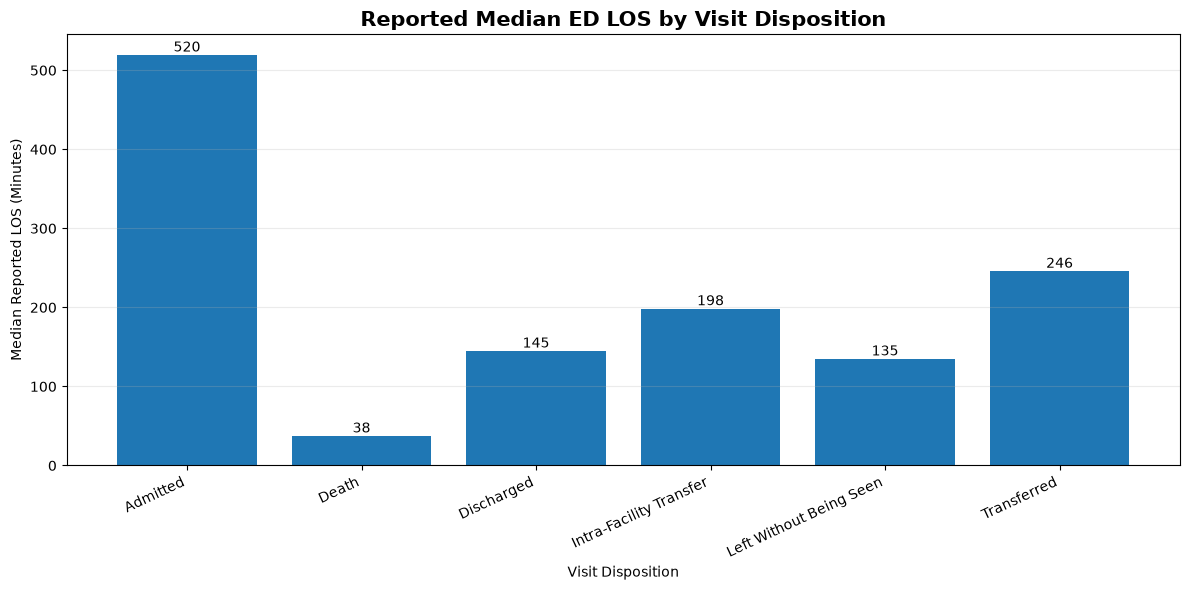

In [81]:
# ============================================================
# H4 VISUAL 1 — REPORTED MEDIAN ED LOS BY VISIT DISPOSITION
# ============================================================

plot_data = (
    h4_summary
    .set_index("visit_disposition")
    .reindex(DISPOSITION_LEVELS)
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    DISPOSITION_LEVELS,
    plot_data["Median_Reported_LOS"],
    color="#1f77b4"
)

plt.title(
    "Reported Median ED LOS by Visit Disposition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Visit Disposition")
plt.ylabel("Median Reported LOS (Minutes)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, plot_data["Median_Reported_LOS"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

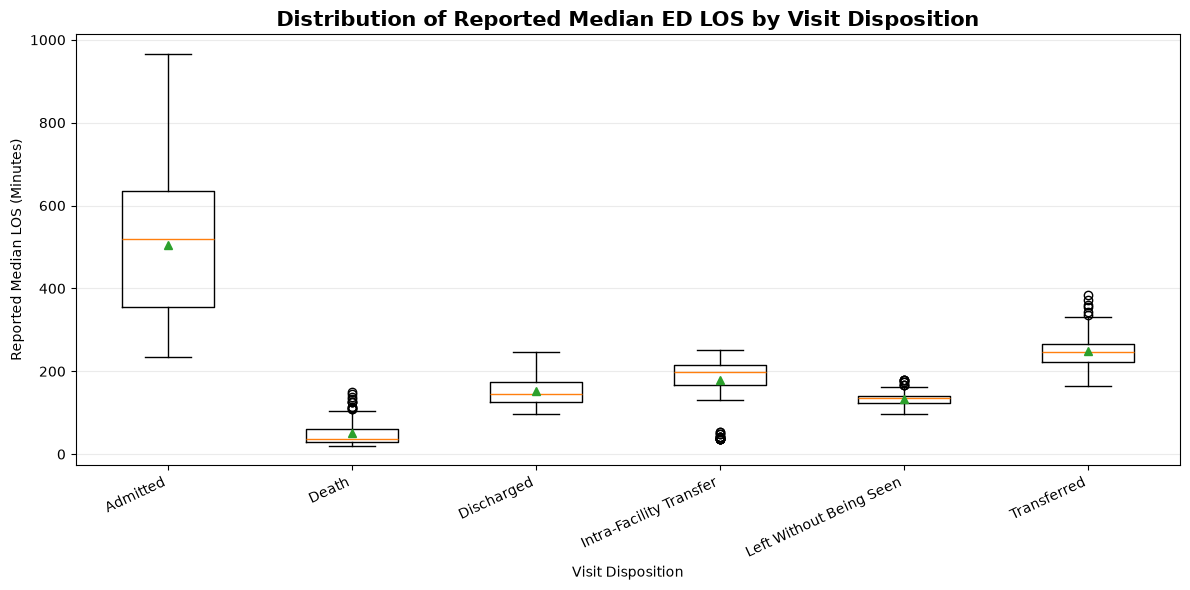

In [82]:
# ============================================================
# H4 VISUAL 2 — DISTRIBUTION OF REPORTED MEDIAN ED LOS
# ============================================================

box_data = [
    h4_df.loc[
        h4_df["visit_disposition"] == disposition,
        "median_los_minutes"
    ]
    .dropna()
    .to_numpy()
    for disposition in DISPOSITION_LEVELS
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    box_data,
    tick_labels=DISPOSITION_LEVELS,
    showmeans=True
)

plt.title(
    "Distribution of Reported Median ED LOS by Visit Disposition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Visit Disposition")
plt.ylabel("Reported Median LOS (Minutes)")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

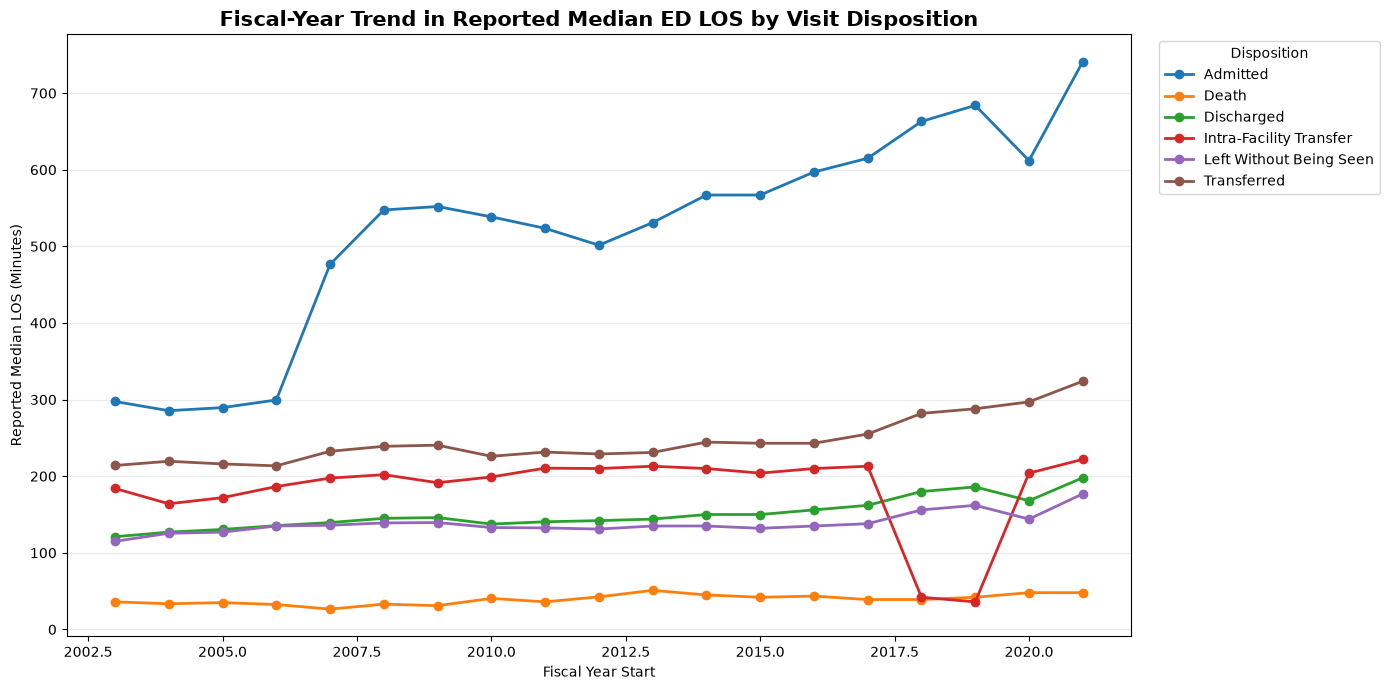

In [83]:
# ============================================================
# H4 VISUAL 3 — FISCAL-YEAR TREND BY DISPOSITION
# ============================================================

year_disposition = (
    h4_df
    .groupby(
        [
            "fiscal_year_start",
            "visit_disposition"
        ],
        observed=True
    )[
        "median_los_minutes"
    ]
    .median()
    .reset_index()
)

plt.figure(figsize=(14, 7))

for disposition in DISPOSITION_LEVELS:
    subset = (
        year_disposition[
            year_disposition["visit_disposition"] == disposition
        ]
        .sort_values("fiscal_year_start")
    )
    plt.plot(
        subset["fiscal_year_start"],
        subset["median_los_minutes"],
        marker="o",
        linewidth=2,
        label=disposition
    )

plt.title(
    "Fiscal-Year Trend in Reported Median ED LOS by Visit Disposition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Fiscal Year Start")
plt.ylabel("Reported Median LOS (Minutes)")
plt.legend(
    title="Disposition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

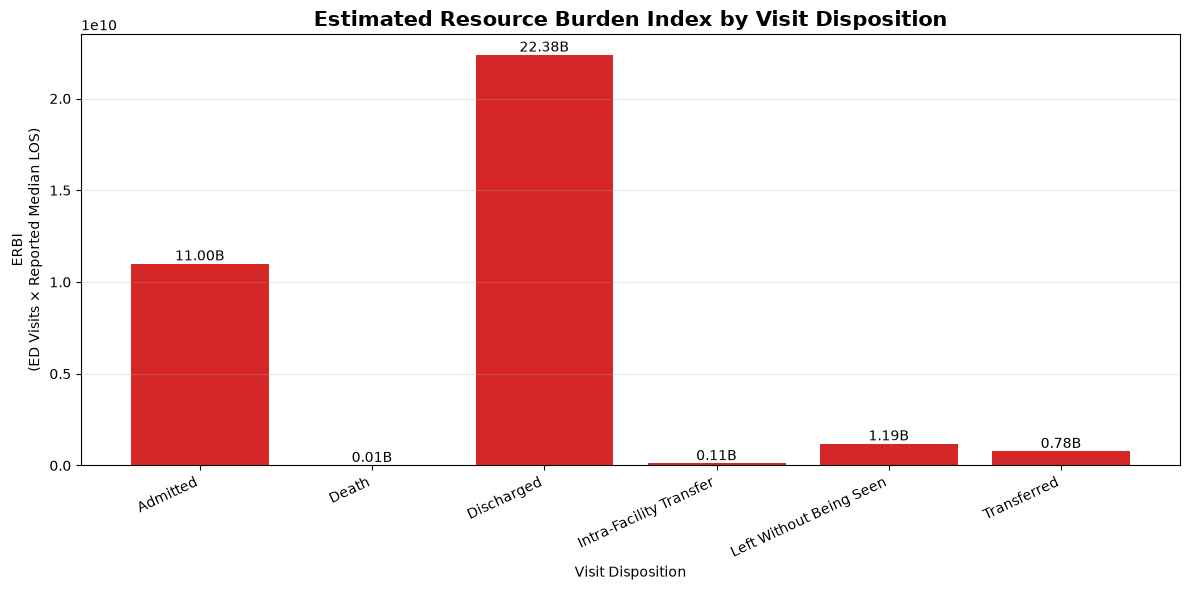

In [84]:
# ============================================================
# H4 VISUAL 4 — ESTIMATED RESOURCE BURDEN INDEX BY DISPOSITION
# ============================================================

erbi_summary = (
    h4_df
    .groupby(
        "visit_disposition",
        observed=True
    )[
        "ERBI"
    ]
    .sum()
    .reindex(
        DISPOSITION_LEVELS
    )
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    DISPOSITION_LEVELS,
    erbi_summary.values,
    color="#d62728"
)

plt.title(
    "Estimated Resource Burden Index by Visit Disposition",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Visit Disposition")
plt.ylabel("ERBI\n(ED Visits × Reported Median LOS)")
plt.xticks(rotation=25, ha="right")

for bar, value in zip(bars, erbi_summary.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value / 1e9:.2f}B",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [85]:
# ============================================================
# H4 — FINAL RESULTS TABLE
# ============================================================

h4_results = pd.DataFrame({
    "Hypothesis": [
        "H4"
    ],
    "Research_Question": [
        "Does reported median ED LOS differ across major visit-disposition categories within the matched fiscal-year, sex, and age-group aggregate data?"
    ],
    "Primary_Test": [
        "Friedman test"
    ],
    "Matched_Blocks": [
        len(complete_matrix)
    ],
    "Disposition_Groups": [
        len(DISPOSITION_LEVELS)
    ],
    "Friedman_Statistic": [
        friedman_statistic
    ],
    "Degrees_of_Freedom": [
        degrees_of_freedom
    ],
    "P_Value": [
        p_value
    ],
    "Alpha": [
        ALPHA
    ],
    "Kendalls_W": [
        kendalls_w
    ],
    "Decision": [
        decision
    ]
})

print("=" * 90)
print("H4 — FINAL RESULTS TABLE")
print("=" * 90)
display(h4_results.round(6))

H4 — FINAL RESULTS TABLE


,Hypothesis,Research_Question,Primary_Test,Matched_Blocks,Disposition_Groups,Friedman_Statistic,Degrees_of_Freedom,P_Value,Alpha,Kendalls_W,Decision
0,H4,Does reported median ED LOS differ across majo...,Friedman test,152,6,703.7260,5,0.0000,0.0500,0.9260,Reject H₀


In [86]:
# ============================================================
# H4 — FINAL INTERPRETATION
# ============================================================

print("=" * 90)
print("H4 — FINAL HYPOTHESIS TEST RESULT")
print("=" * 90)

print("\nResearch Question:")
print(
    "Does reported median ED LOS differ across major "
    "visit-disposition categories within the matched "
    "fiscal-year, sex, and age-group aggregate data?"
)

print("\nPrimary Test:")
print("Friedman test on matched fiscal-year, sex, and age-group blocks.")

print(f"\nFriedman χ² = {friedman_statistic:.4f}")
print(f"df          = {degrees_of_freedom}")
print(f"p           = {p_value:.10g}")
print(f"Kendall's W = {kendalls_w:.4f}")

print(f"\nDecision: {decision}")
print(f"\nConclusion:\n{conclusion}")

print("\nMethodological limitation:")
print(
    "The analysis uses pre-aggregated observations. "
    "Matched blocks represent combinations of fiscal year, "
    "sex, and age group rather than individual patients. "
    "Therefore, findings describe aggregate-level associations "
    "and should not be interpreted as individual-patient "
    "effects or causal relationships."
)

print("\nERBI limitation:")
print(
    "ERBI is an estimated resource-burden proxy calculated "
    "as ED visits multiplied by reported median LOS. "
    "It does not represent actual total ED minutes."
)

H4 — FINAL HYPOTHESIS TEST RESULT

Research Question:
Does reported median ED LOS differ across major visit-disposition categories within the matched fiscal-year, sex, and age-group aggregate data?

Primary Test:
Friedman test on matched fiscal-year, sex, and age-group blocks.

Friedman χ² = 703.7260
df          = 5
p           = 7.684532426e-150
Kendall's W = 0.9260

Decision: Reject H₀

Conclusion:
There is statistically significant evidence that reported median ED LOS differs across the major visit-disposition categories within the matched aggregate data.

Methodological limitation:
The analysis uses pre-aggregated observations. Matched blocks represent combinations of fiscal year, sex, and age group rather than individual patients. Therefore, findings describe aggregate-level associations and should not be interpreted as individual-patient effects or causal relationships.

ERBI limitation:
ERBI is an estimated resource-burden proxy calculated as ED visits multiplied by reported med

In [90]:
# ============================================================
# H4 — AGGREGATE STRUCTURE VALIDATION SUMMARY
# ============================================================

print("=" * 80)
print("H4 AGGREGATE STRUCTURE VALIDATION SUMMARY")
print("=" * 80)

print(f"Total matched blocks                 : {len(complete_matrix):,}")
print(f"Disposition categories per block     : {len(DISPOSITION_LEVELS)}")
print(f"Friedman matrix shape                : {complete_matrix.shape}")
print(f"Friedman chi-square (χ²)             : {friedman_statistic:.4f}")
print(f"Degrees of freedom (df)              : {degrees_of_freedom}")
print(f"p-value                              : {p_value:.10g}")
print(f"Kendall's W                          : {kendalls_w:.4f}")
print(f"Decision                             : {decision}")
print(f"Total post-hoc comparisons           : {len(posthoc):,}")
if not posthoc.empty:
    sig_count = posthoc['Significant'].sum()
    print(f"Significant pairs (Bonferroni)       : {sig_count:,} of {len(posthoc):,}")
print(f"Planned comparisons evaluated        : {len(planned_posthoc):,}")

H4 AGGREGATE STRUCTURE VALIDATION SUMMARY
Total matched blocks                 : 152
Disposition categories per block     : 6
Friedman matrix shape                : (152, 6)
Friedman chi-square (χ²)             : 703.7260
Degrees of freedom (df)              : 5
p-value                              : 7.684532426e-150
Kendall's W                          : 0.9260
Decision                             : Reject H₀
Total post-hoc comparisons           : 15
Significant pairs (Bonferroni)       : 15 of 15
Planned comparisons evaluated        : 2


In [89]:
# ============================================================
# H4 — VARIABLE SAFETY CHECK
# ============================================================

required_h4_variables = [
    "h4_df",
    "friedman_matrix",
    "complete_matrix",
    "friedman_statistic",
    "degrees_of_freedom",
    "p_value",
    "ALPHA",
    "kendalls_w",
    "decision",
    "conclusion",
    "h4_summary",
    "h4_results",
    "posthoc",
    "planned_posthoc"
]

missing_variables = [
    variable
    for variable in required_h4_variables
    if variable not in globals()
]

if missing_variables:
    raise NameError(
        "The following H4 variables are missing: "
        + ", ".join(missing_variables)
    )

print("=" * 80)
print("ALL REQUIRED H4 VARIABLES ARE DEFINED")
print("=" * 80)

for variable in required_h4_variables:
    print(f"  ✓ {variable}")

if p_value < ALPHA:
    if len(posthoc) != 15:
        raise ValueError("Expected 15 H4 pairwise comparisons.")
    if len(planned_posthoc) != 2:
        raise ValueError("Expected 2 planned substantive comparisons.")
    print("\n  ✓ Post-hoc validation passed: 15 pairwise comparisons and 2 planned comparisons.")

ALL REQUIRED H4 VARIABLES ARE DEFINED
  ✓ h4_df
  ✓ friedman_matrix
  ✓ complete_matrix
  ✓ friedman_statistic
  ✓ degrees_of_freedom
  ✓ p_value
  ✓ ALPHA
  ✓ kendalls_w
  ✓ decision
  ✓ conclusion
  ✓ h4_summary
  ✓ h4_results
  ✓ posthoc
  ✓ planned_posthoc

  ✓ Post-hoc validation passed: 15 pairwise comparisons and 2 planned comparisons.
